In [127]:
import numpy as np
from scipy.spatial import ConvexHull
from collections import defaultdict
import matplotlib.pyplot as plt

data = np.genfromtxt("input.txt", delimiter=",", dtype=int)


In [128]:
def largest_rectangle(data: np.ndarray) -> int:
    # largest rectangle has opposite corners on convex hull
    hull = data[ConvexHull(data).vertices]
    n = len(hull)

    # now run exhaustive search on vertices of convex hull
    areas = [
        (abs(hull[i, 1] - hull[j, 1]) + 1) * (abs(hull[i, 0] - hull[j, 0]) + 1)
        for i in range(n)
        for j in range(i + 1, n)
    ]

    return int(max(areas))


largest_rectangle(data)


4781377701

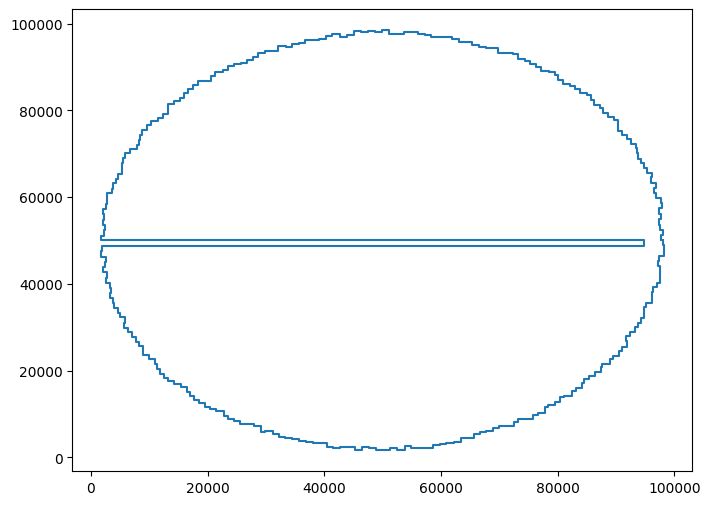

In [129]:
def plotter(data: np.ndarray) -> None:
    plt.figure(figsize=(8, 6))
    plt.plot(data[:, 0], data[:, 1], marker=None)
    plt.show()

plotter(data)


In [130]:
def largest_rectangle_2(data: np.ndarray) -> int:
    vertical = defaultdict(list) # store all vertical edges
    horizontal = defaultdict(list) # store all horizontal edges
    n = len(data)

    prev = data[-1]
    for p in data:
        c1, r1 = prev
        c2, r2 = p

        if c1 == c2: # vertical edge
            y1, y2 = sorted([r1, r2])
            vertical[c1].append((y1, y2))
        elif r1 == r2: # horizontal edge
            x1, x2 = sorted([c1, c2])
            horizontal[r1].append((x1, x2))

        prev = p

    def contained(level: int, a: int, b: int, horiz: bool, top: bool) -> bool:
        if horiz:
            for x, edges in vertical.items():
                if a < x < b:
                    for y1, y2 in edges:
                        if top:
                            if y1 < level <= y2:
                                return False
                        else:
                            if y1 <= level < y2:
                                return False
            return True
        else:
            for y, edges in horizontal.items():
                if a < y < b:
                    for x1, x2 in edges:
                        if top:
                            if x1 < level <= x2:
                                return False
                        else:
                            if x1 <= level < x2:
                                return False
            return True

    max_area = 0
    for i in range(n):
        c1, r1 = data[i]
        for j in range(i+1, n):
            c2, r2 = data[j]

            x1, x2 = sorted([c1, c2])
            y1, y2 = sorted([r1, r2])

            # check all edges are contained
            if (contained(y1, x1, x2, horiz=True, top=False) and 
                contained(y2, x1, x2, horiz=True, top=True) and 
                contained(x1, y1, y2, horiz=False, top=False) and
                contained(x2, y1, y2, horiz=False, top=True)):
                max_area = max(max_area, (x2 - x1 + 1)*(y2 - y1 + 1))

    return int(max_area)

largest_rectangle_2(data)


1470616992